In [ ]:
import pandas as pd
df = pd.read_csv("/content/StudentPerformanceFactors.csv")
df.head()


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [ ]:
df.columns

Index(['Hours_Studied', ' Attendance', ' Parental_Involvement',
       ' Access_to_Resources', ' Extracurricular_Activities', ' Sleep_Hours',
       ' Previous_Scores', ' Motivation_Level', ' Internet_Access',
       ' Tutoring_Sessions', ' Family_Income', ' Teacher_Quality',
       ' School_Type', ' Peer_Influence', ' Physical_Activity',
       ' Learning_Disabilities', ' Parental_Education_Level',
       ' Distance_from_Home', ' Gender', ' Exam_Score'],
      dtype='object')

In [ ]:
df.dtypes

,0
Hours_Studied,int64
Attendance,int64
Parental_Involvement,object
Access_to_Resources,object
Extracurricular_Activities,object
Sleep_Hours,int64
Previous_Scores,int64
Motivation_Level,object
Internet_Access,object
Tutoring_Sessions,int64


In [ ]:
df.select_dtypes(include='object').columns

Index([' Parental_Involvement', ' Access_to_Resources',
       ' Extracurricular_Activities', ' Motivation_Level', ' Internet_Access',
       ' Family_Income', ' Teacher_Quality', ' School_Type', ' Peer_Influence',
       ' Learning_Disabilities', ' Parental_Education_Level',
       ' Distance_from_Home', ' Gender'],
      dtype='object')

In [ ]:
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype(str).str.strip().str.title()

In [ ]:
df.columns = df.columns.str.strip()

In [ ]:
ordinal_maps = {
    'Parental_Involvement': {'Low': 0, 'Medium': 1, 'High': 2},
    'Access_to_Resources': {'Low': 0, 'Medium': 1, 'High': 2},
    'Motivation_Level': {'Low': 0, 'Medium': 1, 'High': 2},
    'Family_Income': {'Low': 0, 'Medium': 1, 'High': 2},
    'Teacher_Quality': {'Low': 0, 'Medium': 1, 'High': 2},
    'Peer_Influence': {'Negative': 0, 'Neutral': 1, 'Positive': 2},
    'Parental_Education_Level': {'High School': 0, 'College': 1, 'Postgraduate': 2},
    'Distance_from_Home': {'Near': 0, 'Moderate': 1, 'Far': 2}
}

for col, mapping in ordinal_maps.items():
    df[col] = df[col].map(mapping)

In [ ]:
binary_maps = {
    'Internet_Access': {'No': 0, 'Yes': 1},
    'Extracurricular_Activities': {'No': 0, 'Yes': 1},
    'Learning_Disabilities': {'No': 0, 'Yes': 1},
    'Gender': {'Male': 0, 'Female': 1},
}

for col,mapping in binary_maps.items():
  df[col] = df[col].map(mapping)

In [ ]:
df['School_Type'] = df['School_Type'].map({'Public': 0, 'Private': 1})

In [ ]:
df = df.dropna(subset=['Exam_Score'])

In [ ]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
numeric_cols = numeric_cols.drop('Exam_Score')

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

In [ ]:
categorical_cols = df.columns.difference(numeric_cols).difference(['Exam_Score'])

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [ ]:
df.isnull().sum()

,0
Hours_Studied,0
Attendance,0
Parental_Involvement,0
Access_to_Resources,0
Extracurricular_Activities,0
Sleep_Hours,0
Previous_Scores,0
Motivation_Level,0
Internet_Access,0
Tutoring_Sessions,0


In [ ]:
df.isnull().sum().sort_values(ascending=False)


,0
Hours_Studied,0
Attendance,0
Parental_Involvement,0
Access_to_Resources,0
Extracurricular_Activities,0
Sleep_Hours,0
Previous_Scores,0
Motivation_Level,0
Internet_Access,0
Tutoring_Sessions,0


In [ ]:
df['Access_to_Resources'].unique()
df['Parental_Involvement'].unique()
df['Teacher_Quality'].unique()
df['Motivation_Level'].unique()
df['Family_Income'].unique()
df['Peer_Influence'].unique()
df['Parental_Education_Level'].unique()
df['Distance_from_Home'].unique()


array([0., 1., 2.])

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# Features and target
X = df.drop(columns=['Exam_Score'])
y = df['Exam_Score']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

mae, r2


(0.44317606500719176, 0.7708850030067915)

In [ ]:
import pandas as pd

coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}).sort_values(by='Coefficient', ascending=False)

coef_df


,Feature,Coefficient
3,Access_to_Resources,1.046931
2,Parental_Involvement,1.005717
8,Internet_Access,0.954067
4,Extracurricular_Activities,0.577730
10,Family_Income,0.539868
11,Teacher_Quality,0.523870
13,Peer_Influence,0.521714
7,Motivation_Level,0.519976
9,Tutoring_Sessions,0.508728
16,Parental_Education_Level,0.481647


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

MAE: 1.073982602118003
R2: 0.6696878341390176


In [ ]:
from sklearn.model_selection import cross_val_score
import numpy as np

scores = cross_val_score(model, X, y, cv=5, scoring="r2")
print("Mean R2:", np.mean(scores))

Mean R2: 0.7264475258734449


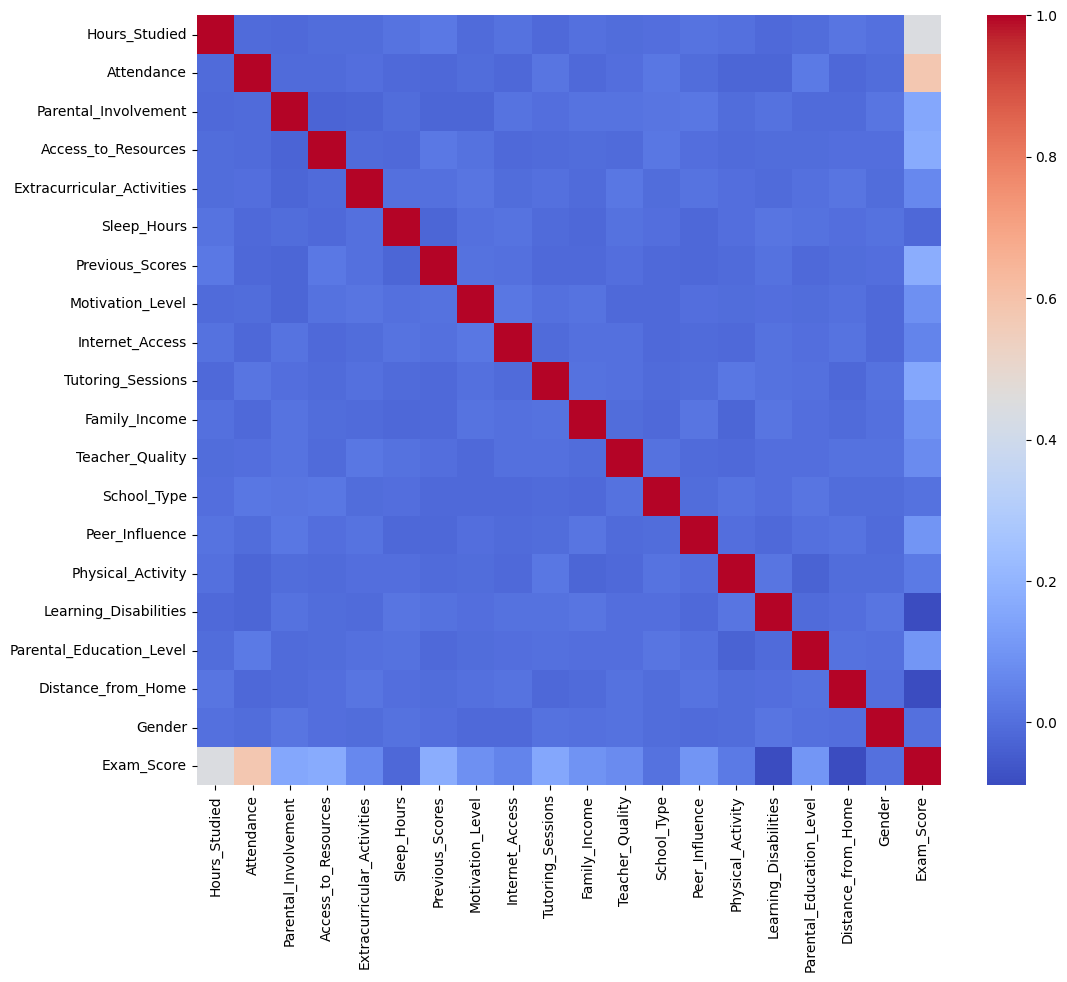

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.show()

In [ ]:
!pip uninstall -y shap numpy
!pip install numpy==1.26.4 shap==0.44.1


Found existing installation: shap 0.44.1
Uninstalling shap-0.44.1:
  Successfully uninstalled shap-0.44.1
Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
  Using cached shap-0.44.1-cp312-cp312-linux_x86_64.whl
Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.0 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 wh

In [ ]:
import shap
explainer = shap.LinearExplainer(model, X_train)
shap_values = explainer.shap_values(X_test)

In [ ]:
X_train.to_csv("/content/background_data.csv", index=False)

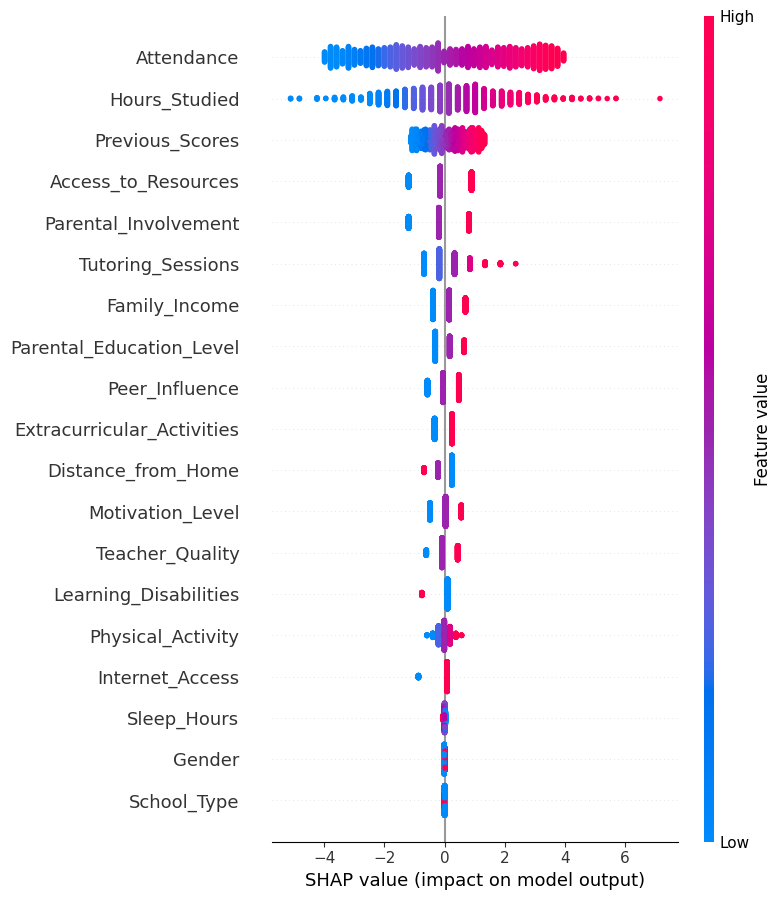

In [ ]:
shap.summary_plot(shap_values, X_test)

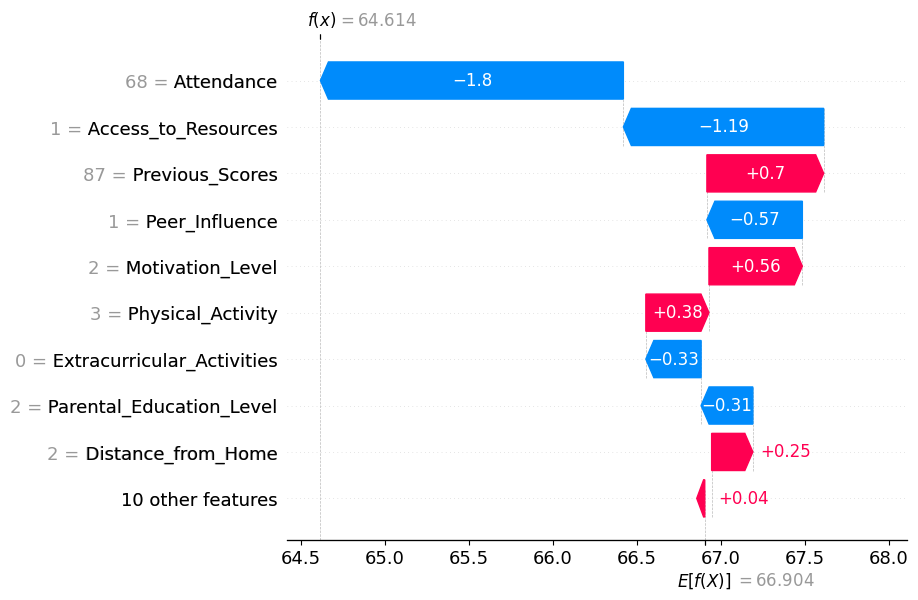

In [ ]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[0],
        base_values=explainer.expected_value,
        data=X_test.iloc[10],
        feature_names=X_test.columns
    )
)

In [ ]:
import joblib
joblib.dump(model, 'my_model.pkl')

['my_model.pkl']

In [ ]:
print(X.columns.tolist())

['Hours_Studied', 'Attendance', 'Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours', 'Previous_Scores', 'Motivation_Level', 'Internet_Access', 'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender']


In [ ]:
sample = [[
6.5, 82, 2, 1, 1, 7, 75, 2, 1, 2, 0, 1, 0, 2, 1.5, 0, 1, 0, 0
]]

model.predict(sample)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([65.71142946])